## Fake News Detection 

## **Reading the Dataset**

In [31]:
# Importing the required libraries

# Importing library for data manipulation and analysis
import pandas as pd

# Library for statistical data visualization
import seaborn as sns

# Library for creating visualizations
import matplotlib.pyplot as plt

# Importing the RandomForestClassifier algorithm
from sklearn.ensemble import RandomForestClassifier

# Library for splitting data into training and testing sets
from sklearn.model_selection import train_test_split

 # Library for evaluating model accuracy
from sklearn.metrics import accuracy_score , f1_score, confusion_matrix

In [32]:
#Loading the dataset
df = pd.read_csv("Fake News Detection Dataset.csv")

In [33]:
#Lets see the first 10 rows of the dataset
df.head(10)

,ID,Word_Count,Number_of_Sentence,Unique_Words,Average_Word_Length,Label
0,1606,10,4,24,6.176750,1
1,3718,10,8,25,5.826770,1
2,2634,10,7,18,4.619040,1
3,5560,10,6,18,4.961424,1
4,7494,10,4,21,4.114324,1
5,3159,39,5,16,4.582874,1
6,7232,11,4,21,5.756046,1
7,7509,11,5,21,4.502690,1
8,1509,11,6,24,3.943672,1
9,1657,11,8,19,5.419068,1


In [34]:
#Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   4500 non-null   int64  
 1   Word_Count           4500 non-null   int64  
 2   Number_of_Sentence   4500 non-null   int64  
 3   Unique_Words         4500 non-null   int64  
 4   Average_Word_Length  4500 non-null   float64
 5   Label                4500 non-null   int64  
dtypes: float64(1), int64(5)
memory usage: 211.1 KB


## **Summary Statistics**

In [35]:
#Description of dataset
df.describe()

,ID,Word_Count,Number_of_Sentence,Unique_Words,Average_Word_Length,Label
count,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000,4500.000000
mean,5469.140000,53.934000,8.934667,24.943333,4.968105,0.329556
std,2599.193059,24.872743,3.407847,11.540708,1.152394,0.470104
min,1002.000000,10.000000,4.000000,5.000000,3.000385,0.000000
25%,3228.750000,35.000000,6.000000,17.000000,3.980553,0.000000
50%,5449.500000,52.000000,9.000000,22.000000,4.906200,0.000000
75%,7706.750000,75.000000,12.000000,33.000000,5.996111,1.000000
max,9999.000000,100.000000,15.000000,50.000000,6.999799,1.000000


## **Exploratory Data Analysis (EDA)**

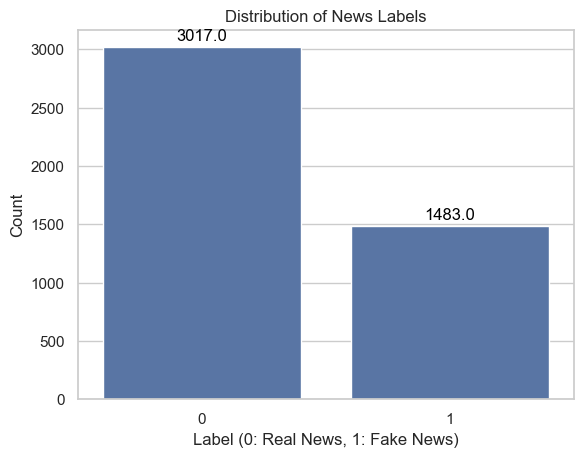

In [36]:
# Plotting the distribution of labels
ax = sns.countplot(x='Label', data=df)

# Adding labels and title
plt.xlabel('Label (0: Real News, 1: Fake News)')
plt.ylabel('Count')
plt.title('Distribution of News Labels')
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

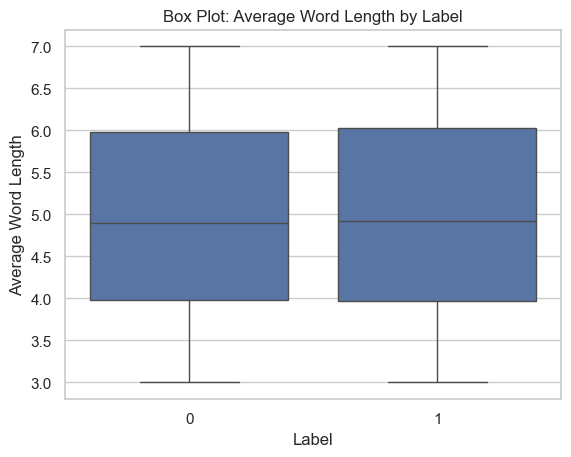

In [37]:
# Set the style of the plots
sns.set(style="whitegrid")

# Create a bar plot
sns.boxplot(x="Label", y="Average_Word_Length", data=df)
plt.title("Box Plot: Average Word Length by Label")
plt.xlabel("Label")
plt.ylabel("Average Word Length")
plt.show()

From this plot, **The average word length variable is similarly distributed in real and fake news.**

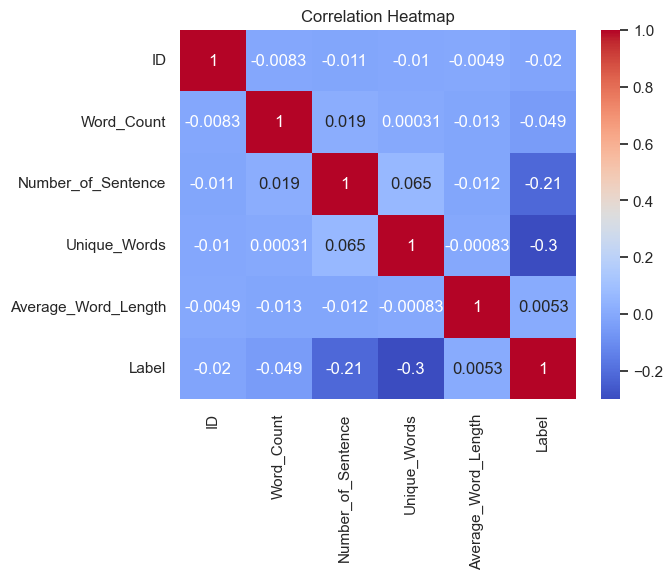

In [43]:
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [44]:
# Separate features (X) and target variable (y)
X = df.drop(['Label',"ID"], axis=1)
y = df['Label']
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)

In [45]:
# Train the RandomForest model
rf_model = RandomForestClassifier(n_estimators =150,max_depth =5,random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Support Vector Machine": LinearSVC()
}

accuracy_results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy_results[name] = accuracy_score(y_test, y_pred)

# Add Random Forest accuracy (already trained in original code)
accuracy_results["Random Forest"] = accuracy_score(y_test, rf_model.predict(X_test))

# Display results
for model, acc in accuracy_results.items():
    print(f"{model} Accuracy: {acc:.4f}")

Logistic Regression Accuracy: 0.6348
Naive Bayes Accuracy: 0.5556
Support Vector Machine Accuracy: 0.6319
Random Forest Accuracy: 0.8904


In [47]:
# Make predictions on the train data using the trained model
y_train_pred = rf_model.predict(X_train)

In [48]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy on test data:", accuracy)

Accuracy on test data: 0.6318518518518519


In [49]:
# Calculate F1 score
from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.23655913978494625


"The F1 score is a metric that evaluates the performance of a model by considering both precision and recall. It provides a balanced measure of the model's ability to make accurate positive predictions (precision) and identify actual positive instances (recall). An **F1 score of 0.859 indicates that the model is achieving a good balance between precision and recall, which is a positive sign**.

<Axes: >

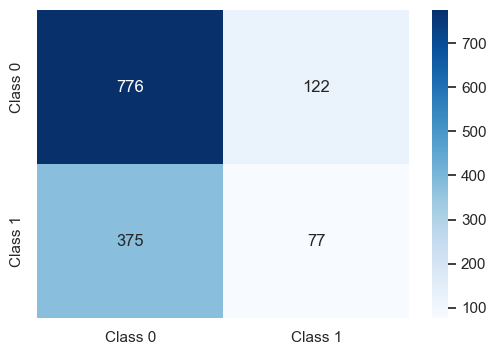

In [50]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

# Define class labels
class_labels = ['Class 0', 'Class 1']

# Plot the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)